# Práctica 1 — Introducción a cuadernos Jupyter y librerías de aprendizaje automático

**Materia:** Introducción al Aprendizaje Automático  
**Tema:** Primer acercamiento a un pipeline de ML con MNIST  
**Nombre y apellido:**  
**Fecha de entrega:**  Miercoles 01/04/2026, 23:59

---

## Objetivos

En esta práctica vas a:

- repasar el uso básico de cuadernos Jupyter / Colab;
- conocer librerías comunes de aprendizaje automático: **pandas, matplotlib, scikit-learn, keras, tensorflow y pytorch**;
- trabajar con una versión filtrada del conjunto de datos **MNIST**;
- entender la idea de **vectorización de imágenes**;
- entrenar un clasificador simple;
- evaluar el modelo mediante una métrica básica como **accuracy**.

## Instrucciones

1. Hacé una copia personal de este cuaderno antes de editarlo.
2. Completá todas las celdas pedidas.
3. No borres las celdas de enunciado.
4. Ejecutá el cuaderno de principio a fin antes de entregar.
5. Dejá visibles los resultados y gráficos.
6. Entregá el archivo `.ipynb` con el nombre indicado por la cátedra.

## Parte 0 — Objetivos Generales

MNIST es un conjunto de imágenes de dígitos escritos a mano. Cada imagen tiene tamaño **28 × 28** píxeles.

En esta práctica vamos a seguir un pipeline simple:

1. Cargar datos con bibliotecas de deep learning.
2. Explorar y filtrar parte del dataset con pandas.
3. Visualizar ejemplos con matplotlib.
4. Transformar las imágenes de 28×28 a vectores de longitud 784.
5. Entrenar un clasificador pequeño con scikit-learn.
6. Evaluar el resultado con la metrica de exactitud.
7. Comparar cómo distintas bibliotecas participan en un flujo de trabajo de ML.

In [ ]:
# Instalación básico del entorno

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
import torch

from tensorflow import keras

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("PyTorch:", torch.__version__)

Python: 3.12.12
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1
TensorFlow: 2.19.0
Keras: 3.13.2
PyTorch: 2.10.0+cpu


## Parte 1 — Carga de MNIST con Keras / TensorFlow

Vamos a usar `keras.datasets.mnist` para descargar el dataset de manera simple.

In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


### Pregunta 1.1
Observá las dimensiones de `X_train`.  
¿Qué representa cada eje de este arreglo?

_Reemplazá este texto por tu respuesta._

## Parte 2 — Visualización inicial con matplotlib

Antes de entrenar cualquier modelo, conviene mirar algunos datos.

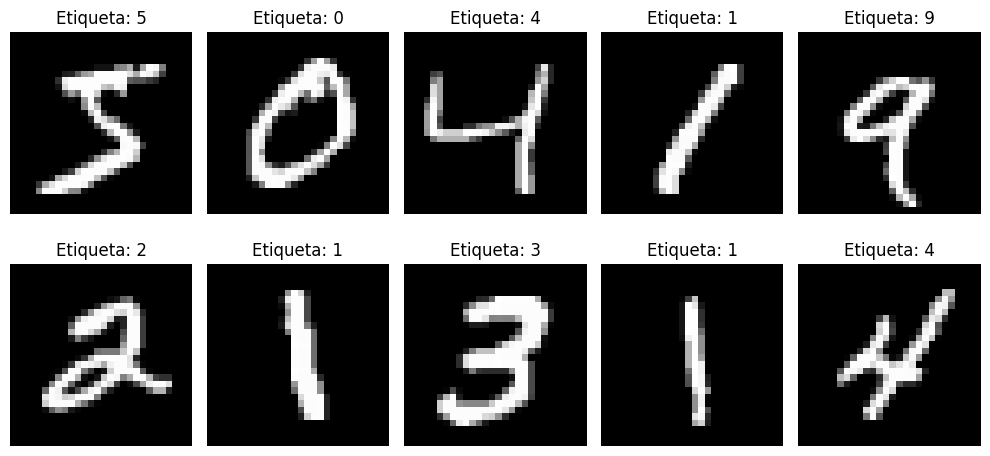

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Ejercicio 2.1
Ahora tu turno: imprimv seis ejemplos del dígito 1.


In [ ]:
#Tu código aquí

## Parte 3 — Uso de pandas para filtrar el dataset

Ahora vamos a construir un `DataFrame` con las etiquetas y luego vamos a filtrar el dataset para trabajar solo con algunos dígitos.

Para simplificar la tarea, vamos a quedarnos solo con los dígitos:

- **0**
- **1**
- **2**
- **3**

Esto reduce el problema y permite enfocarnos en el pipeline.

In [ ]:
# Creamos un DataFrame solo con las etiquetas
df_train = pd.DataFrame({"label": y_train})
df_test = pd.DataFrame({"label": y_test})

print(df_train.head())
print("\nCantidad de ejemplos por clase en train:")
print(df_train["label"].value_counts().sort_index())

   label
0      5
1      0
2      4
3      1
4      9

Cantidad de ejemplos por clase en train:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [ ]:
# Filtrado con pandas: nos quedamos solo con los dígitos 0, 1, 2 y 3
digitos_elegidos = [0, 1, 2, 3]

mask_train = df_train["label"].isin(digitos_elegidos)
mask_test = df_test["label"].isin(digitos_elegidos)

X_train_filtrado = X_train[mask_train.values]
y_train_filtrado = y_train[mask_train.values]

X_test_filtrado = X_test[mask_test.values]
y_test_filtrado = y_test[mask_test.values]

print("Train filtrado:", X_train_filtrado.shape, y_train_filtrado.shape)
print("Test filtrado:", X_test_filtrado.shape, y_test_filtrado.shape)

Train filtrado: (24754, 28, 28) (24754,)
Test filtrado: (4157, 28, 28) (4157,)


### Ejercicio 3.1
Mostrá cuántos ejemplos hay de cada clase **después del filtrado**, tanto en entrenamiento como en prueba.


In [ ]:
#Tu código aquí

## Parte 4 — De imagen 28×28 a vector de longitud 784

Muchos modelos clásicos de machine learning no reciben matrices 2D como entrada, sino vectores.

Por eso, una imagen de 28×28 se puede **vectorizar** en un vector de tamaño:

28 × 28 = 784

Esto no cambia la información total, pero sí cambia la forma en que la representamos.

In [ ]:
print("Forma original de una imagen:", X_train_filtrado[0].shape)

X_train_vec = X_train_filtrado.reshape(X_train_filtrado.shape[0], -1)
X_test_vec = X_test_filtrado.reshape(X_test_filtrado.shape[0], -1)

print("Forma vectorizada de X_train:", X_train_vec.shape)
print("Forma vectorizada de X_test:", X_test_vec.shape)

Forma original de una imagen: (28, 28)
Forma vectorizada de X_train: (24754, 784)
Forma vectorizada de X_test: (4157, 784)


### Ejercicio 4.1



Tomá un vector de $\text{X_train_vec}$, volvelo a una imagen de 28x28 e imprimi la imagen resultante usando matplotlib.

In [ ]:
#Tu código aquí

## Parte 5 — Normalización de datos

Los valores de los píxeles van de 0 a 255.  
Una práctica habitual es escalar esos valores al intervalo [0, 1].

In [ ]:
X_train_vec = X_train_vec.astype("float32") / 255.0
X_test_vec = X_test_vec.astype("float32") / 255.0

print("Valor mínimo en train:", X_train_vec.min())
print("Valor máximo en train:", X_train_vec.max())

Valor mínimo en train: 0.0
Valor máximo en train: 1.0


### Pregunta 5.1



Investiga que ventaja tiene la normalización de datos en el ambito del AA.

_Reemplazá este texto por tu respuesta._

## Parte 6 — Un pequeño ejemplo con PyTorch

Aunque en esta práctica el clasificador principal lo entrenaremos con scikit-learn, también queremos ver cómo PyTorch representa datos.

Vamos a convertir una pequeña parte del dataset a tensores.

In [ ]:
X_torch = torch.tensor(X_train_vec[:8], dtype=torch.float32)
y_torch = torch.tensor(y_train_filtrado[:8], dtype=torch.long)

print("Tensor de entrada en PyTorch:")
print("shape =", X_torch.shape)
print("dtype =", X_torch.dtype)

print("\nTensor de etiquetas en PyTorch:")
print("shape =", y_torch.shape)
print("dtype =", y_torch.dtype)

Tensor de entrada en PyTorch:
shape = torch.Size([8, 784])
dtype = torch.float32

Tensor de etiquetas en PyTorch:
shape = torch.Size([8])
dtype = torch.int64


### Pregunta 6.1
¿Cuál es la diferencia conceptual entre:

- un `numpy.ndarray`
- un `tensor` de PyTorch?

No hace falta una respuesta muy técnica; basta con una explicación clara y general.


_Reemplazá este texto por tu respuesta._

## Parte 7 — Entrenamiento de un clasificador simple con scikit-learn

Vamos a entrenar un clasificador clásico.  
Para esta primera práctica usaremos **Regresion Logistica**.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_vec, y_train_filtrado)

y_pred = modelo.predict(X_test_vec)

acc = accuracy_score(y_test_filtrado, y_pred)
print(f"Exactitud del modelo: {acc:.4f}")

Exactitud del modelo: 0.9788


### Ejercicio 7.1
Guardá el valor de exactitud en porcentaje y mostralo con 2 decimales.


In [ ]:
#Tu código aquí

## Parte 8 — Análisis de resultados

Además de accuracy, es útil mirar más detalles.

In [ ]:
print("Reporte de clasificación:\n")
print(classification_report(y_test_filtrado, y_pred))

cm = confusion_matrix(y_test_filtrado, y_pred)
print("Matriz de confusión:")
print(cm)

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.96      1032
           3       0.97      0.97      0.97      1010

    accuracy                           0.98      4157
   macro avg       0.98      0.98      0.98      4157
weighted avg       0.98      0.98      0.98      4157

Matriz de confusión:
[[ 970    1    6    3]
 [   1 1127    4    3]
 [  10   10  989   23]
 [   1    4   22  983]]


### Ejercicio 8.1
Respondé brevemente:

1. ¿Qué significa exactitud?
2. ¿Puede un modelo tener exactitud alta y aun así cometer errores importantes?
3. ¿Por qué conviene mirar también la matriz de confusión?




_Reemplazá este texto por tu respuesta._

## Parte 9 — Visualización de aciertos y errores

Vamos a mirar algunos ejemplos del conjunto de prueba y comparar la etiqueta real con la predicción.

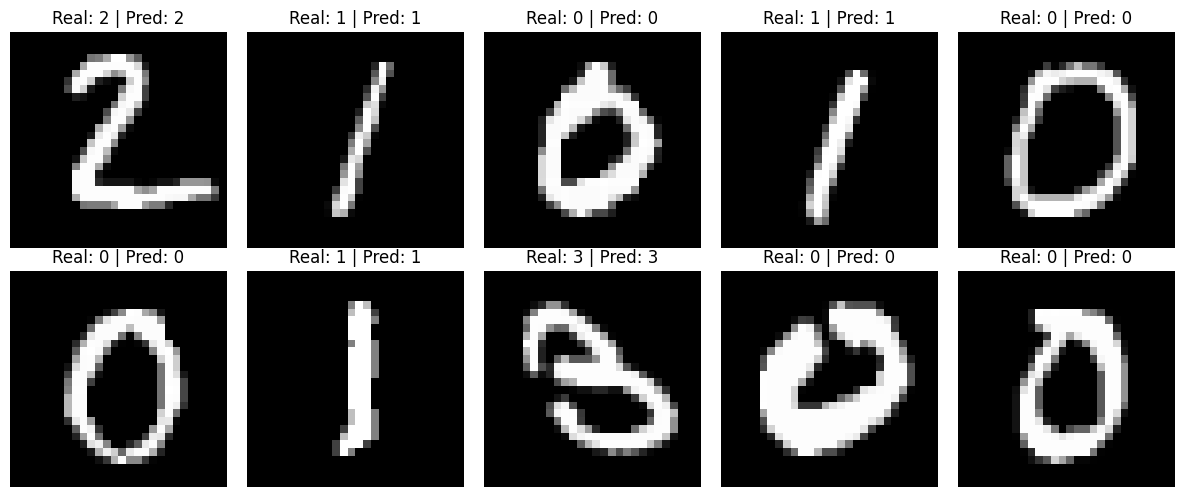

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_filtrado[i], cmap="gray")
    ax.set_title(f"Real: {y_test_filtrado[i]} | Pred: {y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Ejercicio 9.1
Buscá un ejemplo de error del modelo (clasificación no coincide con la imagen) y mostralo en una figura.

Pista: podés encontrar los índices donde `y_test_filtrado != y_pred`.


In [ ]:
#Tu código aquí

## Parte 10 — Relación entre bibliotecas

Hasta acá usamos varias herramientas. La idea no es memorizar todo, sino entender el rol de cada una.

### Resumen

- **pandas**: para organizar etiquetas y filtrar subconjuntos.
- **matplotlib**: para visualizar imágenes y resultados.
- **keras / tensorflow**: para descargar MNIST fácilmente.
- **scikit-learn**: para entrenar un clasificador clásico y evaluar.
- **pytorch**: para ver cómo representar datos como tensores.

En problemas reales, muchas veces se combinan varias bibliotecas en un mismo pipeline.

## Parte 11 - Preguntas teóricas

En el ejercicio de clasificación utilizando el conjunto de datos MNIST:

a) ¿Cómo clasificarías estos datos según su estructura?  
b) ¿Cómo los clasificarías según su representación?  
c) ¿Cómo los clasificarías según su etiquetado?

En cada caso, justifica brevemente tu respuesta.



_Reemplazá este texto por tu respuesta._

## Actividad opcional para grado // obligatoria para posgrado

Pensá un tema de interes en tu area de estudio y buscá si se ha usado alguna herramienta de AA para estudiarlo (ejemplo, papers cientificos o articulos de divugacion). Podes explicar brevemente que problema se trato y en forma muy general, que logro la herramienta de AA. No es necesario expandir demasiado



_Reemplazá este texto por tu respuesta._


## Entrega

Antes de entregar, verificá lo siguiente:

- [ ] completé todas las consignas;
- [ ] ejecuté el cuaderno de principio a fin;
- [ ] dejé los resultados visibles;
- [ ] guardé el archivo con el nombre correcto.

Fin de la práctica.